# leveraging AVISO while gaussian filtering SWOT data

In [1]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from numba import njit, prange
#, int32, float64

## numba code for gaussian filtering

In [2]:
@njit()
def _dist_geo(lon1, lat1, lon2, lat2):
    """Computes the Haversine distance in kilometres between two points
    :param x: first point or points as array, each as array of latitude, longitude in degrees
    :param y: second point or points as array, each as array of latitude, longitude in degrees
    :return: distance between the two points in kilometres
    """
    deg2rad = np.pi/180.
    llat1 = lat1 * deg2rad
    llat2 = lat2 * deg2rad
    llon1 = lon1 * deg2rad
    llon2 = lon2 * deg2rad
    arclen = 2 * np.arcsin(
        np.sqrt(
            (np.sin((llat2 - llat1) / 2)) ** 2
            + np.cos(llat1) * np.cos(llat2) * (np.sin((llon2 - llon1) / 2)) ** 2
        )
    )
    earth_radius = 6370e3  # approximate Earth radius at 40degN in meters
    # https://en.wikipedia.org/wiki/Earth_radius
    return arclen * earth_radius

@njit()
def _gauss2d(d, sigma):
    sigma2 = sigma**2
    d2 = d**2
    #return (0.5/np.pi/sigma2) * np.exp(-0.5/sigma2*d**2)
    return np.exp(-0.5*d2/sigma2) # shortcut expecting normalization down the line

@njit(parallel=True)
def nb_filter_gaussian(
    lon0, lat0, v0, mask0,
    sigma, truncate,
):
    """filter data with Gaussian filter"""
    vf = np.zeros_like(v0)
    weight0 = np.zeros_like(v0)
    n0 = len(vf)

    sigma_x_truncate = sigma*truncate
    
    for i0 in prange(n0):
        # loop over primary data points
        for j0 in range(n0):
            d = _dist_geo(lon0[i0], lat0[i0], lon0[j0], lat0[j0])
            if mask0[j0]>0 and d<sigma_x_truncate:
                w = _gauss2d(d, sigma)
                weight0[i0] += w
                vf[i0] += v0[j0]*w
        vf[i0] = vf[i0]/weight0[i0]

    return vf, weight0

@njit(parallel=True)
def nb_filter_gaussian_combined(
    lon0, lat0, v0, mask0,
    lon1, lat1, v1, 
    area_ratio,
    sigma, truncate,
):
    """filter data with Gaussian filter leveraging external data for points where the primary 
    data source has no nearby points"""
    vf = np.zeros_like(v0)
    weight0 = np.zeros_like(v0)
    weight1 = np.zeros_like(v0)
    n0 = len(vf)
    n1 = len(v1)

    sigma_x_truncate = sigma*truncate
    
    for i0 in prange(n0):
        # loop over primary data points
        for j0 in range(n0):
            d = _dist_geo(lon0[i0], lat0[i0], lon0[j0], lat0[j0])
            if mask0[j0]>0 and d<sigma_x_truncate:
                w = _gauss2d(d, sigma)
                weight0[i0] += w
                vf[i0] += v0[j0]*w
        # loop over secondary data points
        for i1 in range(n1):
            d = _dist_geo(lon0[i0], lat0[i0], lon1[i1], lat1[i1])
            if d<sigma_x_truncate:
                w = _gauss2d(d, sigma)*area_ratio
                weight1[i0] += w
                vf[i0] += v1[i1]*w
                    
        vf[i0] = vf[i0]/(weight0[i0]+weight1[i0])

    return vf, weight0, weight1

@njit(parallel=True)
def nb_mask_grid(lon, lat, lon1, lat1, dl):
    """ mask secondary data if close to primary one """
    n = len(lon)
    n1 = len(lon1)
    mask1 = np.ones_like(lon1)

    for i1 in prange(n1):
        for i in range(n):
            d = _dist_geo(lon[i], lat[i], lon1[i1], lat1[i1])
            if d<dl:
                mask1[i1]=0
                break

    return mask1

## load data

In [3]:
aviso = xr.open_dataset("dt_europe_allsat_phy_l4_20230601_20231013.nc")
# select only area where swath is ... adjust for swath 16
aviso = aviso.sel(longitude=slice(2,7), latitude=slice(36, 44))

swot = xr.open_zarr("3_538.zarr")
swot = swot.where(swot["latitude_nadir"].compute()>36, drop=True)
swot["adt"] = swot["duacs_mean_dynamic_topography"] + swot["duacs_ssha_karin_2_filtered"]

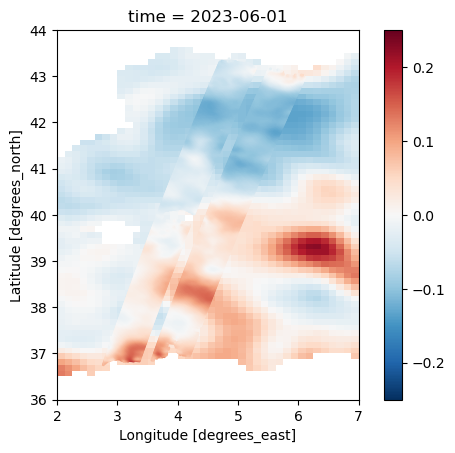

In [4]:
fig, ax = plt.subplots(1,1)
kw = dict(vmin=-.25, vmax=.25, cmap="RdBu_r")
#kw = dict(cmap="RdBu_r")
aviso["adt"].plot(add_colorbar=False, **kw)
im = ax.scatter(swot.longitude, swot.latitude, c=swot["adt"], s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im)

---
## dev/tests

In [5]:
# extract variables from aviso
ds = aviso.squeeze().stack(point=["longitude", "latitude"])
lon1 = ds.longitude.data
lat1 = ds.latitude.data
v1 = ds.adt.data

aviso_stacked = ds

In [6]:
# extract variables from swot
key = "adt"
ds = swot[["longitude", "latitude"]+[key]].stack(point=["num_lines", "num_pixels"]).compute()
mask = xr.where(
    (~np.isnan(ds.longitude)) 
    & (~np.isnan(ds.latitude))
    & (~np.isnan(ds[key])), 
    1, 0,
)
ds["mask"] = mask
swot_stacked = ds

ds =  ds.where(mask).fillna(0.)
lon = ds.longitude.data
lat = ds.latitude.data
v = ds[key].data
mask = mask.data

### dev mask building

In [7]:
%%time
# 20s on laptop with unsmoothed data, only has to be performed once though
# 1s with 2km data

#dl = 250. # m, unsmoothed data
dl = 2e3 # m
mask1 = nb_mask_grid(lon, lat, lon1, lat1, dl)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


CPU times: user 1.41 s, sys: 23.6 ms, total: 1.43 s
Wall time: 560 ms


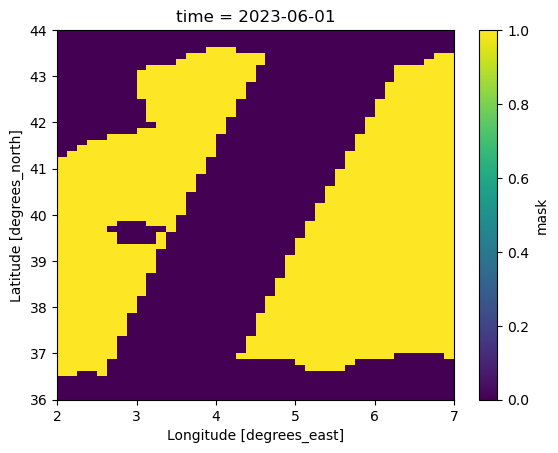

In [8]:
aviso_stacked["mask0"] = ~np.isnan(aviso_stacked["adt"])
aviso_stacked["mask1"] = ("point", mask1)
aviso_stacked["mask"] = aviso_stacked["mask0"] * aviso_stacked["mask1"]
aviso_stacked["mask"].unstack().plot(x="longitude")

In [9]:
# subsample secondary (aviso) data
ds = aviso_stacked.where( aviso_stacked.mask>0, drop=True)
lon1 = ds.longitude.data
lat1 = ds.latitude.data
v1 = ds.adt.data

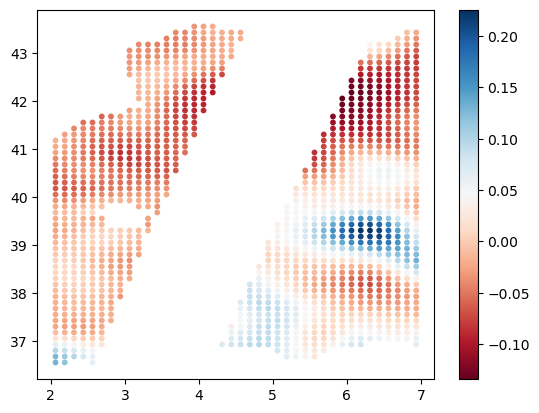

In [10]:
fig, ax = plt.subplots(1,1)
im = ax.scatter(lon1, lat1, c=v1, s=10, cmap="RdBu")
plt.colorbar(im)

In [11]:
dlon = float(aviso.longitude.diff("longitude").median())
dlat = float(aviso.latitude.diff("latitude").median())
_lat = float(aviso.latitude.median())
unit_area_aviso = float(dlon*np.cos(np.deg2rad(_lat))*dlat *(111e3)**2)

unit_area_swot = dl**2
area_ratio = unit_area_aviso/unit_area_swot
print(f"weight of aviso points vs swot points = {area_ratio:.1f}")

weight of aviso points vs swot points = 36.9


In [12]:
%%time

# 1.68s with 2km data

sigma = 20e3
truncate = 4.
area_ratio = unit_area_aviso/unit_area_swot
#area_ratio = 0.

vf, weight0, weight1 = nb_filter_gaussian_combined(
    lon, lat, v, mask,
    lon1, lat1, v1, 
    area_ratio,
    sigma, truncate,
)

swot_stacked["vf"] = ("point", vf)
swot_stacked["weight0"] = ("point", weight0)
swot_stacked["weight1"] = ("point", weight1)

# remask data
swot_stacked["vf"] = swot_stacked["vf"].where( swot_stacked["mask"] )

_swot = swot_stacked.unstack()

CPU times: user 17.6 s, sys: 79.7 ms, total: 17.6 s
Wall time: 2.87 s


(36.5, 43.5)

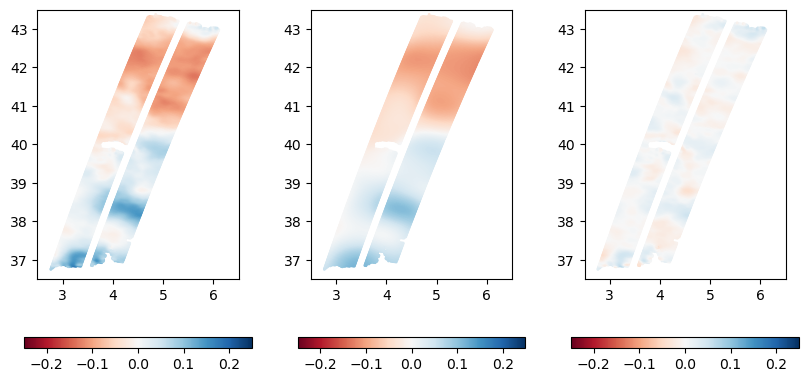

In [13]:

fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = _swot.adt
ax = axes[0]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = _swot.vf
ax = axes[1]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = _swot.adt - _swot.vf
ax = axes[2]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

Text(0.5, 1.0, 'cumulated weight aviso')

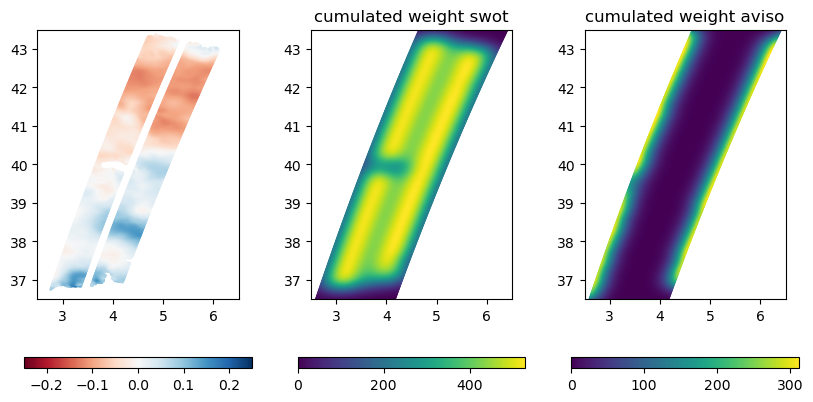

In [14]:
fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = _swot.adt
ax = axes[0]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = _swot["weight0"]
ax = axes[1]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("cumulated weight swot")

da = _swot["weight1"]
ax = axes[2]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("cumulated weight aviso")

---
## wrapped methods and example

In [15]:

# original script
def apply_gaussian_filter(swot_image, cutoff, mask, dx, dy):
    """
    Filter swot_image with a gaussian filter
    input : 
        swot_image : 2D array, image swot
        cutoff :  float, cutoff length (width at mid height of the gaussian filter)
        mask : 2D array with 0 out of swot swath and 1 within
        dx : float, x direction time step
        dy : float, y direction time step - not used here ...?
    """
    from scipy.ndimage import convolve1d
    import scipy.signal.windows as wdw
    
    # Gaussian a la mano
    lambda_cutoff = cutoff/dx
    sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
    Mg = int(2 * np.round(4*lambda_cutoff)+1)
    gaussian = wdw.gaussian(Mg, std = sigma_cutoff)
    fg = xr.DataArray(convolve1d(convolve1d(swot_image.fillna(0), gaussian, axis=0), gaussian, axis=1), dims=swot_image.dims)#unnromalized
    fm = xr.DataArray(convolve1d(convolve1d(mask, gaussian, axis=0), gaussian, axis=1), dims=mask.dims)#unnormalized
    return xr.DataArray(fg/fm, dims=swot_image.dims)#normalized


def apply_gaussian_filter_nb(
    swot_image, cutoff, mask, dx, 
):
    """
    Filter swot_image with a gaussian filter with numba
    input : 
        swot_image : 2D array, image swot
        cutoff :  float, cutoff length (width at mid height of the gaussian filter) in m
        mask : 2D array with 0 out of swot swath and 1 within
        dx : float, x direction grid step in m
    """
    
    # try being consistent with Margot's initial choice
    sigma = cutoff * np.sqrt(np.log(2))
    truncate = 4.*cutoff/sigma

    # stack fields
    ds = (
        xr.merge([swot_image.rename("v"), mask.rename("mask")])
        .stack(point=["num_lines", "num_pixels"])
    )
    swot_stacked = ds
    ds =  ds.where(ds["mask"]).fillna(0.)
    lon0 = ds["longitude"].data
    lat0 = ds["latitude"].data
    v0 = ds["v"].data
    mask0 = ds["mask"].data

    # filter
    vf, weight0 = nb_filter_gaussian(
        lon0, lat0, v0, mask0,
        sigma, truncate,
    )
    swot_stacked["vf"] = ("point", vf)
    swot_stacked = swot_stacked.assign_coords(
        weight0=("point", weight0),
    )
    
    return swot_stacked["vf"].unstack()


def apply_gaussian_filter_aviso(
    swot_image, cutoff, mask, dx,
    aviso_image,
):
    """
    Filter swot_image with a gaussian filter and aviso outside tracks
    input : 
        swot_image : 2D array, image swot
        cutoff :  float, cutoff length (width at mid height of the gaussian filter) in m
        mask : 2D array with 0 out of swot swath and 1 within
        dx : float, x direction grid step in m
        aviso_image: xr.DataArray
    """
    
    # try being consistent with Margot's initial choice
    sigma = cutoff * np.sqrt(np.log(2))
    truncate = 4.*cutoff/sigma

    # compute relative weights
    dlon = float(aviso_image.longitude.diff("longitude").median())
    dlat = float(aviso_image.latitude.diff("latitude").median())
    _lat = float(aviso_image.latitude.median())
    unit_area_aviso = float(dlon*np.cos(np.deg2rad(_lat))*dlat *(111e3)**2)
    
    unit_area_swot = dx**2
    area_ratio = unit_area_aviso/unit_area_swot
    
    # stack swot fields
    ds = (
        xr.merge([swot_image.rename("v"), mask.rename("mask")])
        .stack(point=["num_lines", "num_pixels"])
    )
    swot_stacked = ds
    ds =  ds.where(ds["mask"]).fillna(0.)
    lon0, lat0 = ds["longitude"].data, ds["latitude"].data
    v0 = ds["v"].data
    mask0 = ds["mask"].data

    # mask and stack aviso fields    
    da = aviso_image.squeeze().stack(point=["longitude", "latitude"])
    lon1, lat1 = da.longitude.data, da.latitude.data
    da = da.assign_coords(
        mask0=xr.where(np.isnan(da), 0, 1),
        mask1=("point", nb_mask_grid(lon0, lat0, lon1, lat1, dl)),
    )
    da = da.where( (da.mask0*da.mask1)>0, drop=True)
    lon1, lat1 = da.longitude.data, da.latitude.data
    v1 = da.data
    
    # filter
    vf, weight0, weight1 = nb_filter_gaussian_combined(
        lon0, lat0, v0, mask0,
        lon1, lat1, v1, 
        area_ratio,
        sigma, truncate,
    )
    swot_stacked["vf"] = ("point", vf)
    swot_stacked = swot_stacked.assign_coords(
        weight0=("point", weight0),
        weight1=("point", weight1),
    )
    
    return swot_stacked["vf"].unstack()

In [16]:
swot = swot[["adt"]].compute()

swot["mask"] = xr.where(
    (~np.isnan(swot.longitude)) 
    & (~np.isnan(swot.latitude))
    & (~np.isnan(swot.adt)),
    1, 0,
)

In [17]:
cutoff = 20e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"])

(36.5, 43.5)

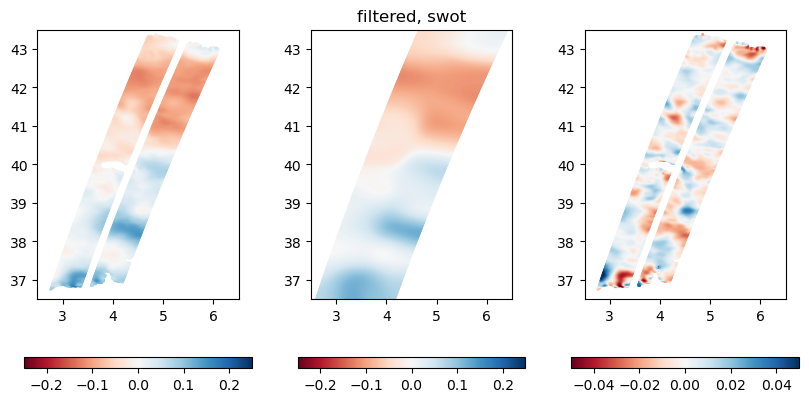

In [18]:

fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = daf
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("filtered, swot")

da = daf - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

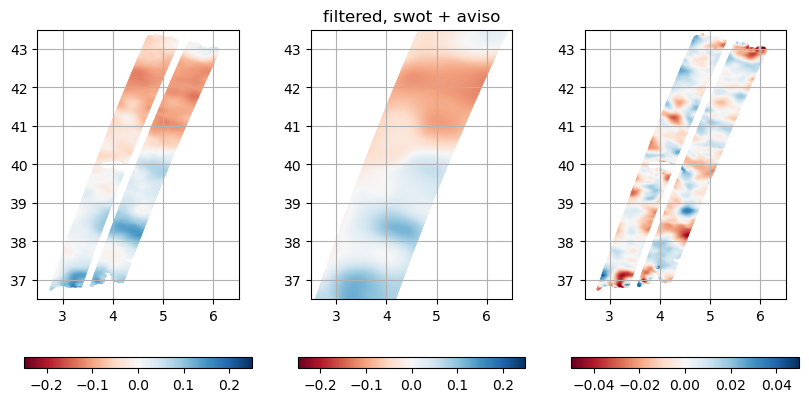

In [19]:
fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
#da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()
ax.set_title("filtered, swot + aviso")

da = daf_aviso - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

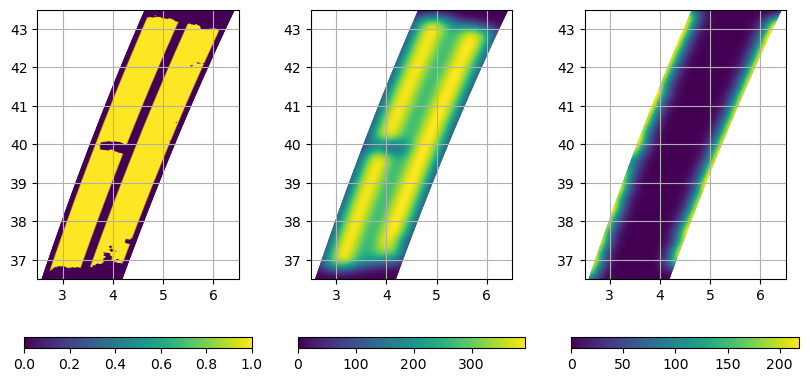

In [20]:
fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf["weight0"]
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso["weight1"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

## !! units: dx, sigma, doivent être en metre ou sinon il faut ajuster code